In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import os, sys, h5py
import pandas as pd

import cobaya
import getdist.plots as gdplt
from getdist import loadMCSamples
%matplotlib inline

from cobaya.samplers.mcmc import plot_progress
from cobaya.yaml import yaml_load_file
from cobaya.run import run
from cobaya import load_samples

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Before running the chains

In [7]:
yaml_file = "/global/homes/c/cpopik/CAPPIBARAS/chains/runchainsLiu.yaml"
yaml_info = cobaya.yaml.yaml_load_file(yaml_file)
for key in yaml_info['likelihood'].keys():
    yaml_info['likelihood'][key]['file'] = yaml_file

In [4]:
yamlinfo = cobaya.yaml.yaml_load_file("/global/homes/c/cpopik/CAPPIBARAS/runchainsLiu.yaml")
pars = [k for k, v in yamlinfo['params'].items() if isinstance(v, dict) and "prior" in v]
parslabel = [v['latex'] for k, v in yamlinfo['params'].items() if isinstance(v, dict) and "prior" in v]
pars0 = {k: v['ref'] for k, v in yamlinfo['params'].items() if isinstance(v, dict) and "prior" in v}

yamlinfo['likelihood'] = {likel: yamlinfo['likelihood'][likel] | yamlinfo['shared'] for likel in yamlinfo['likelihood'].keys()}
model = cobaya.get_model(yamlinfo).likelihood

2025-10-20 14:19:50.669176: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-20 14:19:50.669399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-20 14:19:50.739711: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-20 14:19:50.898690: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-20 14:19:53.973024: W tensorflow/compiler/tf2

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'output_options', 'shared']


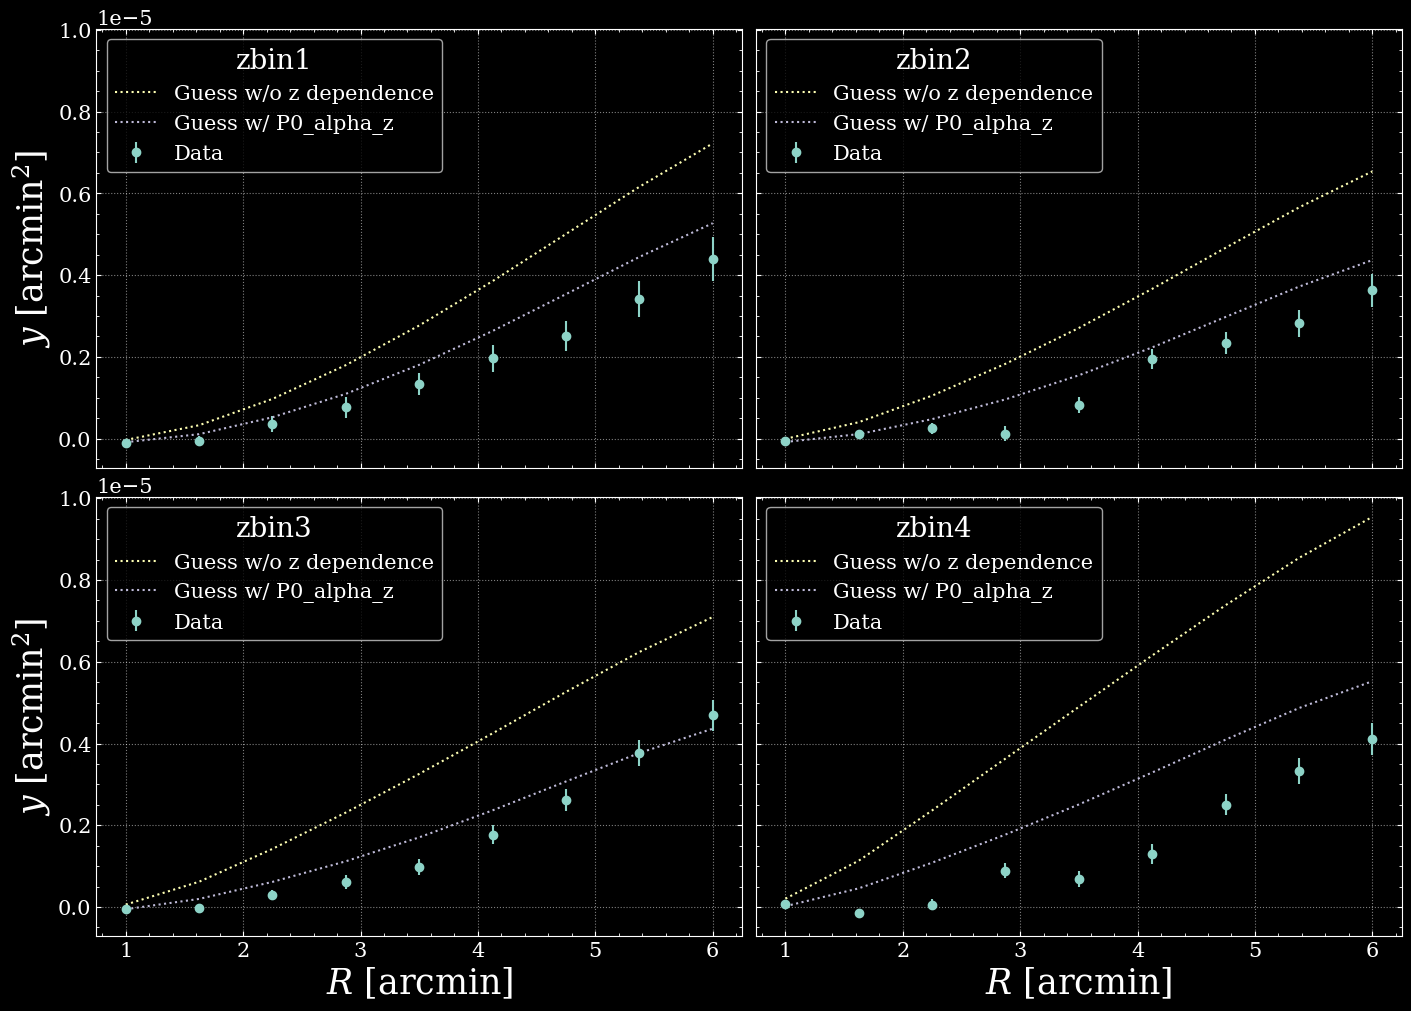

In [7]:
pars01 = pars0 | {'P0_alphaz':-0.8}
pars00= pars0 | {'P0_alphaz':0}

fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    print
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars00), label='Guess w/o z dependence', ls=':')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars01), label='Guess w/ P0_alpha_z', ls=':')
    ax.legend(title=likeli)
plt.show()

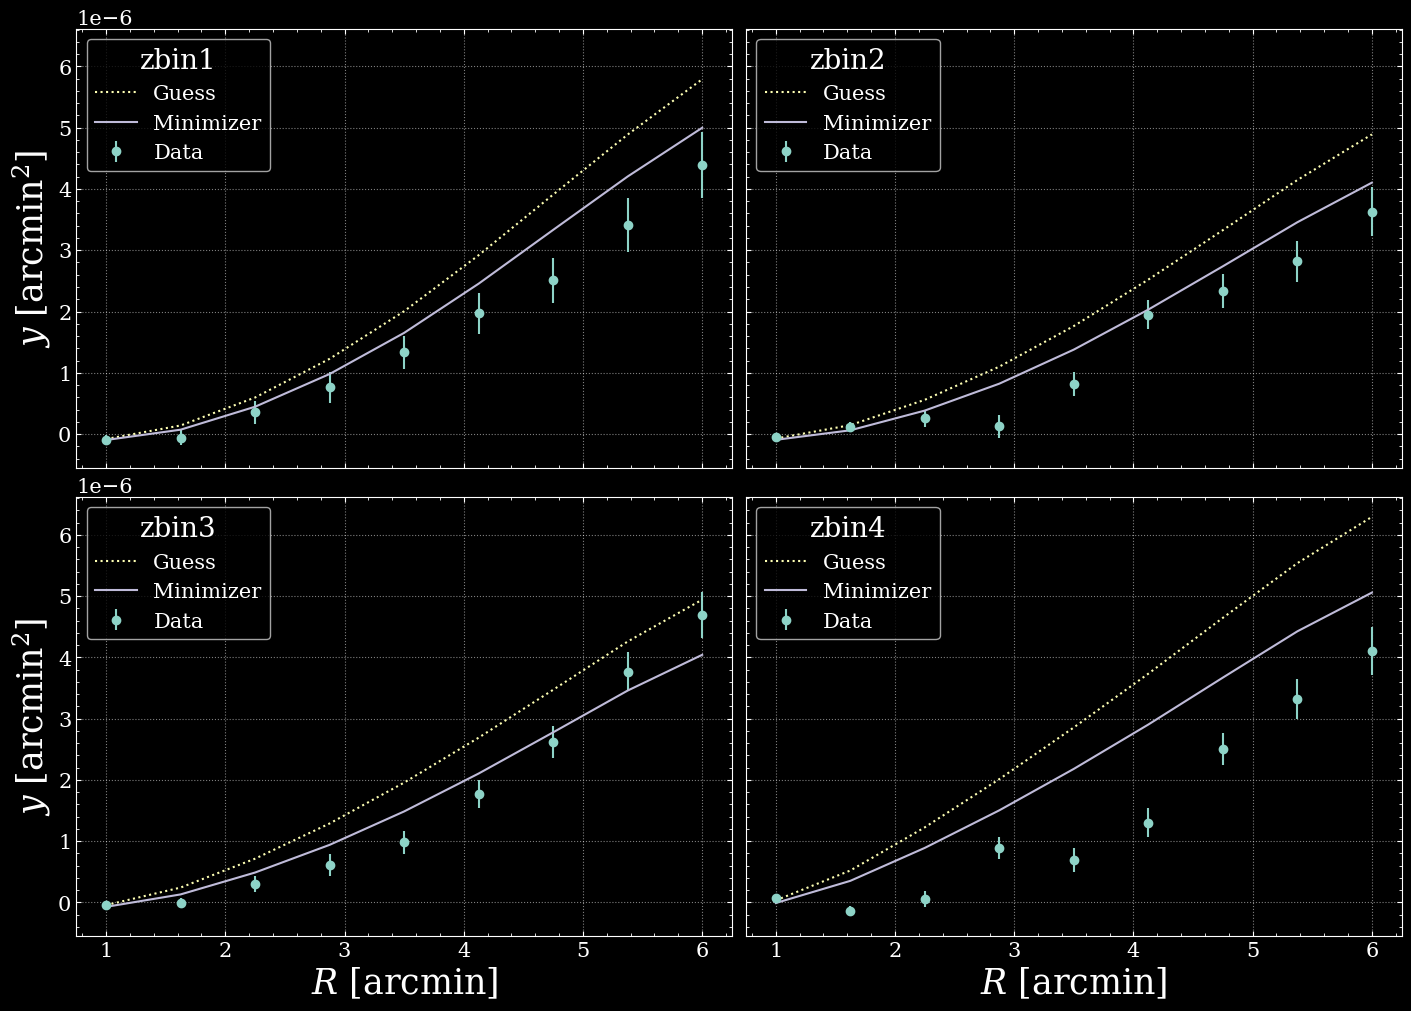

In [10]:
# yamlinfo_min = yamlinfo.copy()
# yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"
# updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)
# minimum = minimizer.products()["minimum"]
# parsfit = {k: minimum[k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars0), label='Guess', ls=':')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(dict(minimum.MAP())), label='Minimizer')
    ax.legend(title=likeli)
plt.show()

# While running the chains

[tools] *WARNING* Last row of chains/10-16-25/Schaantest.progress is incomplete or contains NaNs


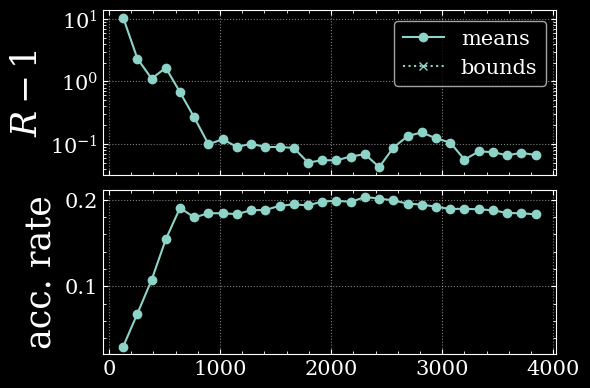

In [ ]:
info_from_yaml = cobaya.yaml.yaml_load_file("/global/homes/c/cpopik/CAPPIBARAS/runchains.yaml")
folder,name = os.path.split(os.path.abspath(info_from_yaml["output"]))

plot_progress(info_from_yaml["output"], figure_kwargs={"figsize": (6,4)})

plt.tight_layout()
plt.show()

# After running the chains

INFO:samplecollection:Loaded 12960 sample points from 'chains/10-16-25/Schaantest.1.txt'


[samplecollection] Loaded 12960 sample points from 'chains/10-16-25/Schaantest.1.txt'


[root] *WARNING* outlier fraction 0.00030864197530864197 


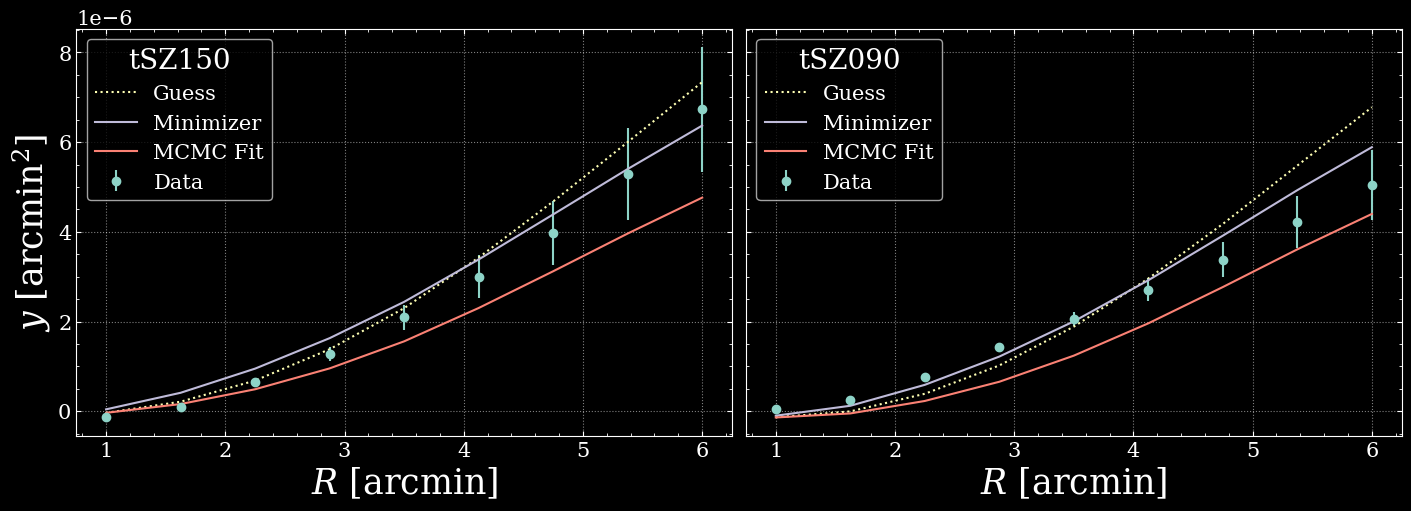

In [108]:
# Export the results to GetDist
gd_sample = load_samples(info_from_yaml["output"], to_getdist=True)

# Analyze and plot
mean = {list(pars0.keys())[i]: gd_sample.getMeans()[i] for i in range(len(pars0.keys()))}
err = np.diag(gd_sample.getCovMat().matrix)**0.5

fig, axs = plt.subplots(1, 2, figsize=(14, 5), layout='constrained', sharex=True, sharey=True)
axs[0].set(ylabel=r'$y$ [arcmin$^2$]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars0), label='Guess', ls=':')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(dict(minimum.MAP())), label='Minimizer')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(mean), label='MCMC Fit')
    ax.set(xlabel=r'$R$ [arcmin]'); ax.legend(title=likeli)

plt.show()

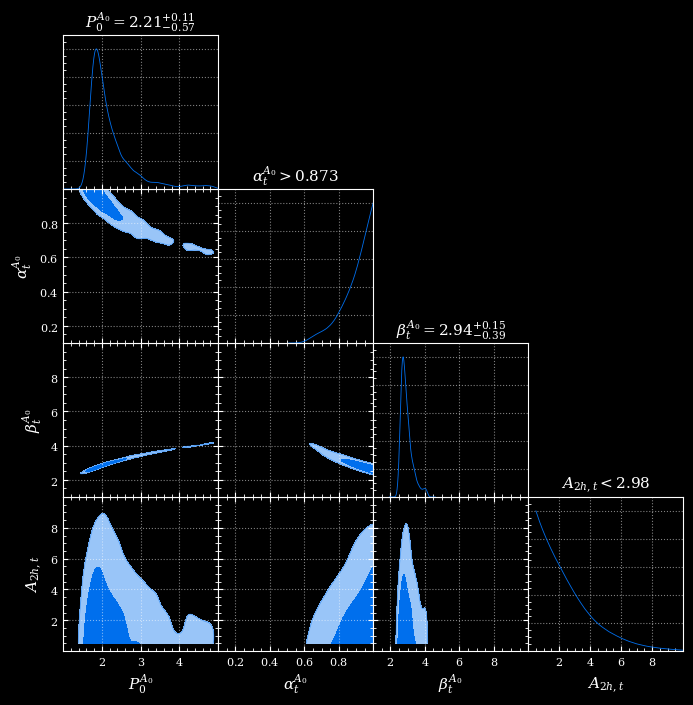

In [78]:
# Export the results to GetDist
folder,name = os.path.split(os.path.abspath(info_from_yaml["output"]))

gdplot = gdplt.get_subplot_plotter(chain_dir=folder)
gdplot.settings.title_limit_fontsize=14
gdplot.triangle_plot(
    gd_sample, list(mean.keys()), filled=True, title_fmt='latex', title_limit=1,
    param_limits={p: (info_from_yaml["params"][p]['prior']['min'], info_from_yaml["params"][p]['prior']['max']) for p in mean.keys()})